<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/RNN_Smart_Home_Energy_Consumption_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)

#Create a Large Smart Home Dataset

In [2]:
hours = 500

np.random.seed(42)

temperature = 28 + 6*np.sin(np.arange(hours)*2*np.pi/24) + np.random.normal(0,1,hours)

humidity = 60 + 10*np.cos(np.arange(hours)*2*np.pi/24) + np.random.normal(0,2,hours)

occupancy = np.random.randint(1,6,hours)

electricity = (
    0.30*temperature +
    0.05*humidity +
    0.90*occupancy +
    np.random.normal(0,0.5,hours)
)

df = pd.DataFrame({
    "Temperature":temperature,
    "Humidity":humidity,
    "Occupancy":occupancy,
    "Electricity":electricity
})

print(df.head())

   Temperature   Humidity  Occupancy  Electricity
0    28.496714  71.852355          4    15.229922
1    29.414650  73.478092          1    13.549161
2    31.647689  65.863119          3    15.630921
3    33.765671  68.197006          5    17.981740
4    32.961999  63.698715          3    16.028675


#Visualize Dataset

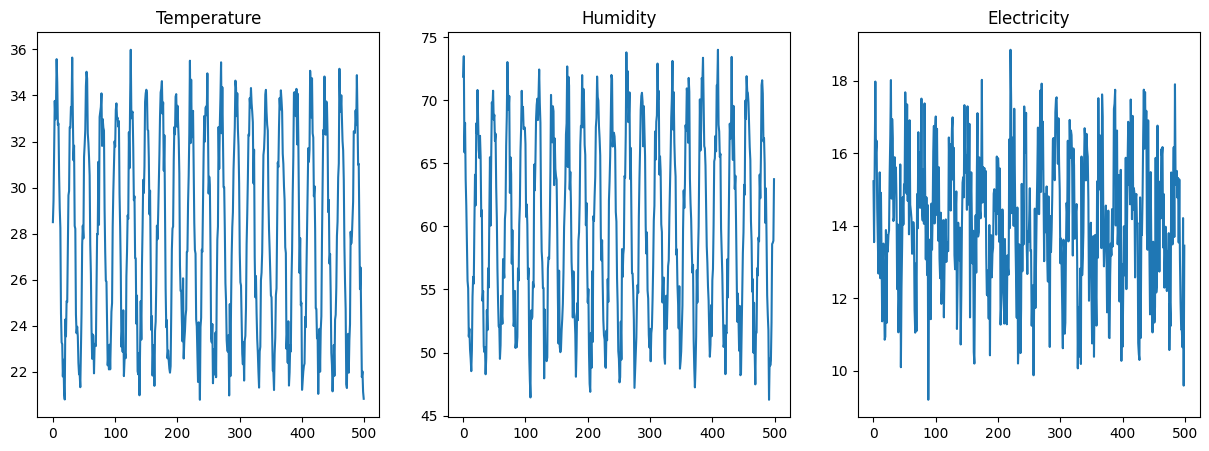

In [3]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(df["Temperature"])
plt.title("Temperature")

plt.subplot(1,3,2)
plt.plot(df["Humidity"])
plt.title("Humidity")

plt.subplot(1,3,3)
plt.plot(df["Electricity"])
plt.title("Electricity")

plt.show()

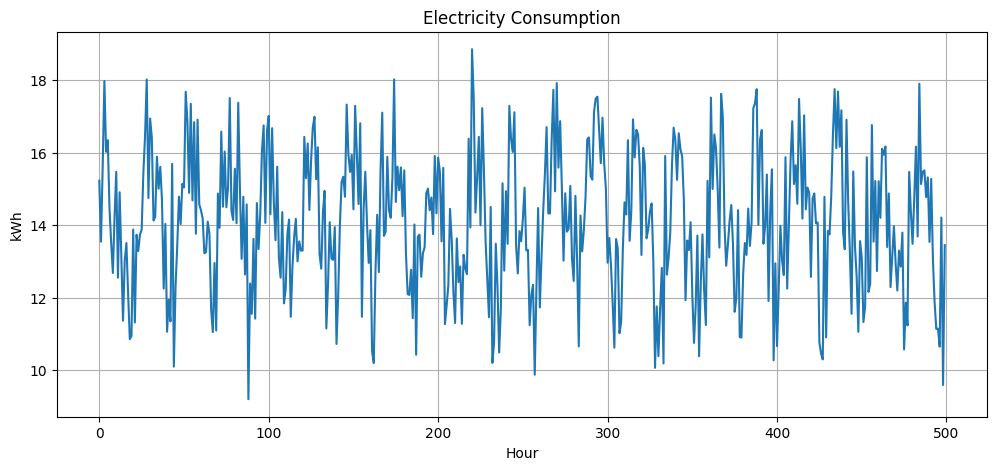

In [4]:
plt.figure(figsize=(12,5))

plt.plot(df["Electricity"])

plt.title("Electricity Consumption")

plt.xlabel("Hour")

plt.ylabel("kWh")

plt.grid()

plt.show()

#Normalize Data

In [5]:
feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

X_features = feature_scaler.fit_transform(
    df[["Temperature","Humidity","Occupancy"]]
)

y_target = target_scaler.fit_transform(
    df[["Electricity"]]
)

#Create Sliding Window Dataset

Use the previous 24 hours to predict the next hour.

In [6]:
window_size = 24

X = []

y = []

for i in range(len(df)-window_size):

    X.append(
        X_features[i:i+window_size]
    )

    y.append(
        y_target[i+window_size]
    )

X = np.array(X)

y = np.array(y)

print(X.shape)

print(y.shape)

(476, 24, 3)
(476, 1)


Meaning::

476 samples

24 previous hours

3 features

#Train-Test Split

In [8]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

#Build Model

In [9]:
model = Sequential([

    SimpleRNN(
        128,
        activation="tanh",
        return_sequences=True,
        input_shape=(window_size,3)
    ),

    Dropout(0.3),

    SimpleRNN(64),

    Dense(64,activation="relu"),

    Dense(32,activation="relu"),

    Dense(1)

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(

    optimizer="adam",

    loss="mse",

    metrics=["mae"]

)

#Adding Callbacks

In [11]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True

)

checkpoint = ModelCheckpoint(

    "best_energy_rnn.keras",

    save_best_only=True

)

In [12]:
history = model.fit(

    X_train,

    y_train,

    validation_data=(X_test,y_test),

    epochs=100,

    batch_size=16,

    callbacks=[early_stop,checkpoint],

    verbose=1

)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0518 - mae: 0.1833 - val_loss: 0.0258 - val_mae: 0.1371
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0266 - mae: 0.1334 - val_loss: 0.0228 - val_mae: 0.1265
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0245 - mae: 0.1275 - val_loss: 0.0245 - val_mae: 0.1331
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0252 - mae: 0.1310 - val_loss: 0.0234 - val_mae: 0.1257
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0227 - mae: 0.1242 - val_loss: 0.0228 - val_mae: 0.1282
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0247 - mae: 0.1284 - val_loss: 0.0230 - val_mae: 0.1258
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0242 - mae: 0.1293 - val_loss: 0.0221 - val_mae: 0.1267
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0225 - mae: 0.1239 - val_loss: 0.0221 - val_mae: 0.1256
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - lo

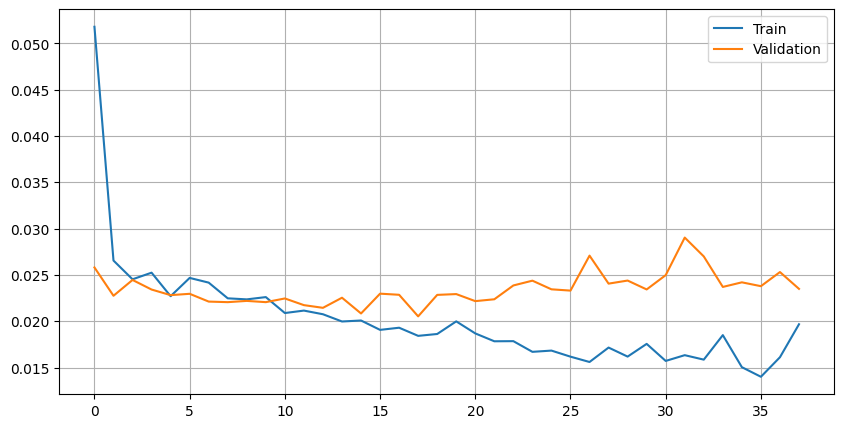

In [13]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"],label="Train")

plt.plot(history.history["val_loss"],label="Validation")

plt.legend()

plt.grid()

plt.show()

In [14]:
pred = model.predict(X_test)

pred = target_scaler.inverse_transform(pred)

actual = target_scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step


#Calculating Loss(MSE,RMSE,MAE)

In [15]:
mse = mean_squared_error(actual,pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(actual,pred)

print("MAE :",mae)

print("RMSE :",rmse)

print("MSE :",mse)

MAE : 1.1438378530286357
RMSE : 1.3841532407665234
MSE : 1.915880193924469


#Actual VS Predicted Graph

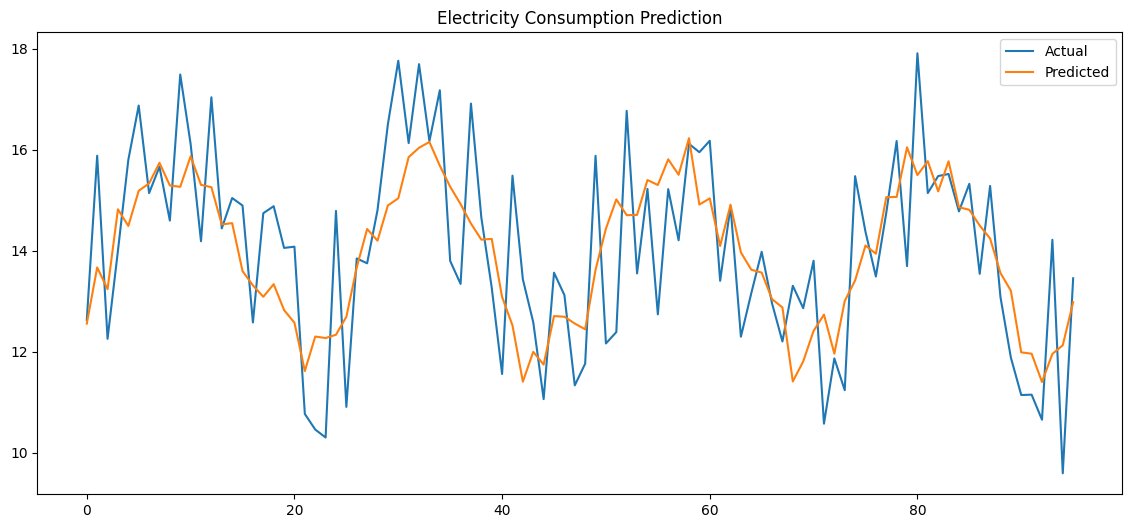

In [16]:
plt.figure(figsize=(14,6))

plt.plot(actual,label="Actual")

plt.plot(pred,label="Predicted")

plt.legend()

plt.title("Electricity Consumption Prediction")

plt.show()

In [17]:
last_window = X_features[-window_size:]

prediction = model.predict(

    last_window.reshape(1,window_size,3),

    verbose=0

)

prediction = target_scaler.inverse_transform(prediction)

print("Predicted Next Hour Electricity Consumption")

print(prediction[0][0],"kWh")

Predicted Next Hour Electricity Consumption
12.65018 kWh


#Predict Next 24 Hours

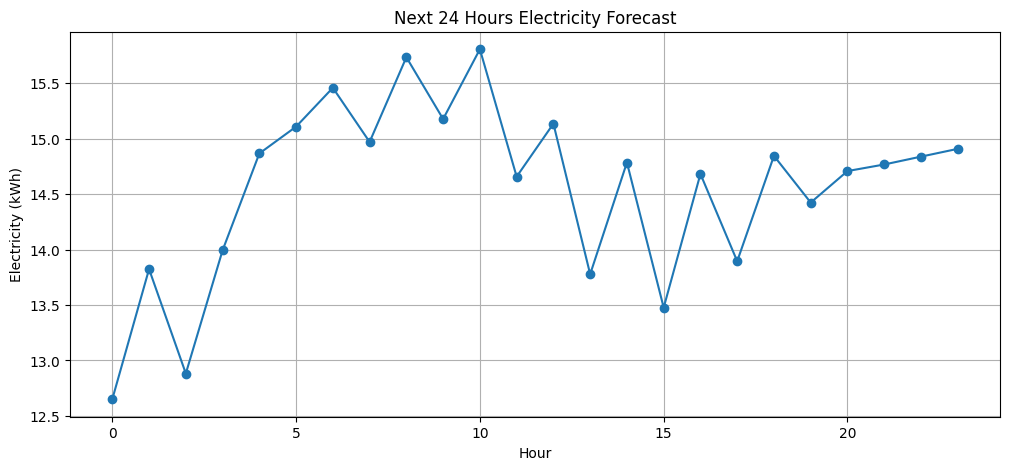

In [18]:
future = []

current = X_features[-window_size:].copy()

for i in range(24):

    pred = model.predict(
        current.reshape(1,window_size,3),
        verbose=0
    )

    value = target_scaler.inverse_transform(pred)[0][0]

    future.append(value)

    new_row = current[-1].copy()

    current = np.vstack([current[1:], new_row])

plt.figure(figsize=(12,5))

plt.plot(future,marker='o')

plt.title("Next 24 Hours Electricity Forecast")

plt.xlabel("Hour")

plt.ylabel("Electricity (kWh)")

plt.grid()

plt.show()

In [19]:
future_hours = np.arange(hours, hours + 24)

future_temperature = (
    28
    + 6*np.sin(future_hours*2*np.pi/24)
    + np.random.normal(0,1,24)
)

future_humidity = (
    60
    + 10*np.cos(future_hours*2*np.pi/24)
    + np.random.normal(0,2,24)
)

future_occupancy = np.random.randint(1,6,24)

future_features = pd.DataFrame({
    "Temperature": future_temperature,
    "Humidity": future_humidity,
    "Occupancy": future_occupancy
})

In [20]:
future_features_scaled = feature_scaler.transform(future_features)

In [21]:
window = X_features[-window_size:].copy()

future_predictions = []

for i in range(24):

    pred = model.predict(
        window.reshape(1, window_size, 3),
        verbose=0
    )

    electricity = target_scaler.inverse_transform(pred)[0][0]

    future_predictions.append(electricity)

    next_features = future_features_scaled[i]

    window = np.vstack([
        window[1:],
        next_features
    ])

In [22]:
forecast = pd.DataFrame({
    "Hour": np.arange(1,25),
    "Temperature": future_temperature.round(1),
    "Humidity": future_humidity.round(1),
    "Occupancy": future_occupancy,
    "Predicted Electricity": np.round(future_predictions,2)
})

print(forecast)

    Hour  Temperature  Humidity  Occupancy  Predicted Electricity
0      1         21.6      67.7          3              12.650000
1      2         24.8      68.6          4              13.880000
2      3         25.7      71.2          4              13.140000
3      4         26.9      69.9          1              14.360000
4      5         27.6      70.6          3              15.240000
5      6         30.1      73.5          2              15.380000
6      7         32.1      67.0          3              15.750000
7      8         32.8      66.9          1              15.310000
8      9         32.5      66.6          4              16.139999
9     10         34.1      62.2          4              15.250000
10    11         35.1      58.9          1              15.910000
11    12         36.0      58.6          2              14.780000
12    13         33.0      57.7          4              15.160000
13    14         33.1      52.6          5              13.430000
14    15  